# L3: Custom Components - News Summarizer

In [1]:
import warnings
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
load_dotenv()

True

In [2]:
import requests

from typing import List

from haystack import Document, Pipeline, component
from haystack.components.builders import PromptBuilder
from haystack.components.generators.openai import OpenAIGenerator
from haystack.components.fetchers import LinkContentFetcher
from haystack.components.converters import HTMLToDocument

## Custom Component Requirements
#### Build a Custom Component

In [4]:
@component
class Greeter:

    @component.output_types(greeting=str)
    def run(self, username: str) -> dict[str, str]:
        return {"greeting": f"Hello {username}!"}

#### Run the Component

In [5]:
greeter = Greeter()

greeter.run(username="Filipe")

{'greeting': 'Hello Filipe!'}

#### Add the Component to a Pipeline

In [6]:
greeter = Greeter()

template = """You will be given the beginning of a dialogue.
Create a short play script using this as the start of the play.
Start of dialogue: {{ dialogue }}
Full script:
"""

prompt = PromptBuilder(template=template)
llm = OpenAIGenerator()

dialogue_builder = Pipeline()
dialogue_builder.add_component("greeter", greeter)
dialogue_builder.add_component("prompt", prompt)
dialogue_builder.add_component("llm", llm)

dialogue_builder.connect("greeter.greeting", "prompt.dialogue")
dialogue_builder.connect("prompt", "llm")

PromptBuilder has 1 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


🚅 Components
  - greeter: Greeter
  - prompt: PromptBuilder
  - llm: OpenAIGenerator
🛤️ Connections
  - greeter.greeting -> prompt.dialogue (str)
  - prompt.prompt -> llm.prompt (str)

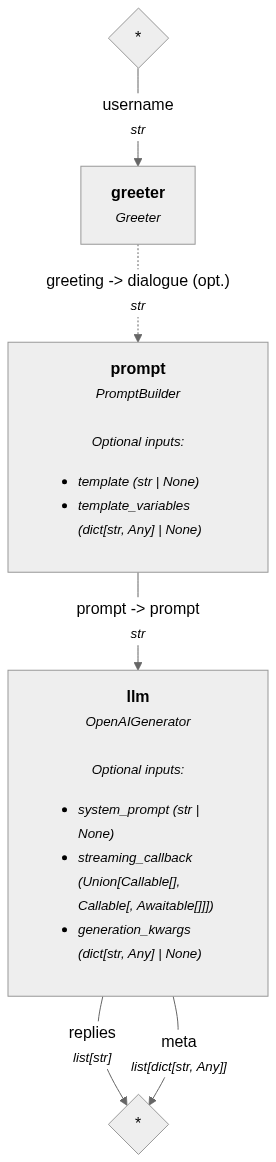

In [7]:
dialogue_builder.show()

In [8]:
dialogue = dialogue_builder.run({"greeter": {"username": "Filipe"}})

print(dialogue["llm"]["replies"][0])

Hello Filipe!

[MARA stands just inside the doorway of a narrow apartment overflowing with plants and books. FILIPE sits at a small table polishing an old, scarred acoustic guitar. Morning light slants across the room. A kettle whistles in the tiny kitchenette and then stops.]

FILIPE
(looks up, mild, guarded)
Mara.

MARA
(smiles that is not quite a smile)
You left the kettle on again. Some things never change.

FILIPE
Some things did. I don't forget things the way I used to.

[MARA crosses, sets a small cardboard box on the table, and sits opposite him. She opens it. Inside: a stack of postcards, stamps, a Polaroid, and three vinyl records with tape around them.]

MARA
I found them in the back of the agency—two boxes labeled "Filipe: Do Not Open." I thought—hilarious, right? Old Filipe's fan mail gone corporate.

FILIPE
(voice soft, a half-laugh)
You always loved scavenger hunts.

MARA
You know why I'm here. (she taps the box) You always did write back.

FILIPE
I wrote when I could.



## Build a Hacker News Summarizer

In [9]:
trending_list = requests.get(url="https://hacker-news.firebaseio.com/v0/topstories.json?print=pretty")

post = requests.get(url=f"https://hacker-news.firebaseio.com/v0/item/{trending_list.json()[0]}.json?print=pretty")

print(post.json())

{'by': 'linolevan', 'descendants': 30, 'id': 46681611, 'kids': [46682857, 46682428, 46682923, 46682879, 46682867, 46682862, 46682663, 46682894, 46682808, 46682389, 46682527, 46682519, 46682580], 'score': 86, 'time': 1768842839, 'title': 'What came first: the CNAME or the A record?', 'type': 'story', 'url': 'https://blog.cloudflare.com/cname-a-record-order-dns-standards/'}


In [11]:
@component
class HackernewsNewestFetcher:
    
    @component.output_types(articles=List[Document])
    def run(self, top_k: int) -> dict[str, List[Document]]:
        articles = []
        return {"articles": articles}

fetcher = HackernewsNewestFetcher()
fetcher.run(top_k=5)

{'articles': []}

In [12]:
@component
class HackernewsNewestFetcher:
    
    def __init__(self) -> None:
        fetcher = LinkContentFetcher()
        converter = HTMLToDocument()
        
        html_conversion_pipeline = Pipeline()
        html_conversion_pipeline.add_component("fetcher", fetcher)
        html_conversion_pipeline.add_component("converter", converter)
        
        html_conversion_pipeline.connect("fetcher", "converter")
        self.html_pipeline = html_conversion_pipeline
        
    @component.output_types(articles=List[Document])
    def run(self, top_k: int) -> dict[str, List[Document]]:
        articles = []
        trending_list = requests.get(url="https://hacker-news.firebaseio.com/v0/topstories.json?print=pretty")

        for id in trending_list.json()[0:top_k]:
            post = requests.get(url=f"https://hacker-news.firebaseio.com/v0/item/{id}.json?print=pretty")
            if "url" in post.json():
                try:
                    article = self.html_pipeline.run(
                        {"fetcher": {"urls": [post.json()["url"]]}}
                    )
                    articles.append(article["converter"]["documents"][0])
                except:
                    print(f"Can't download {post}, skipped")
            elif "text" in post.json():
                try:
                    articles.append(Document(content=post.json()["text"], mesta = {"title": post.json()["title"]}))
                except:
                    print(f"Can't download {post}, skipped")
         
        return {"articles": articles}

In [13]:
fetcher = HackernewsNewestFetcher()
results = fetcher.run(top_k=3)

print(results["articles"])

Can't download <Response [200]>, skipped
[Document(id=43c482764f0d345753d2c3083f151f4604563d66554ec6af45fae218a7314922, content: 'On January 8, 2026, a routine update to 1.1.1.1 aimed at reducing memory usage accidentally triggere...', meta: {'content_type': 'text/html', 'url': 'https://blog.cloudflare.com/cname-a-record-order-dns-standards/'}), Document(id=9904fa4280da832f97092f4bb573546af2e2adf7e16eb191268a06a5400181f1, content: 'apply_chat_template() Is the Safety Switch
How a Single Function Call Gates Safety Alignment in Gemm...', meta: {'content_type': 'text/html', 'url': 'https://teendifferent.substack.com/p/apply_chat_template-is-the-safety'})]


In [14]:
prompt_template = """
You will be provided a few of the top posts in HackerNews.
For each post, provide a brief summary if possible.

Posts:
{% for article in articles %}
    Post:\n
    {{ article.content }}
{% endfor %}
"""

In [15]:
prompt_builder = PromptBuilder(template=prompt_template)

fetcher = HackernewsNewestFetcher()
llm = OpenAIGenerator()

summarizer_pipeline = Pipeline()
summarizer_pipeline.add_component("fetcher", fetcher)
summarizer_pipeline.add_component("prompt", prompt_builder)
summarizer_pipeline.add_component("llm", llm)

summarizer_pipeline.connect("fetcher.articles", "prompt.articles")
summarizer_pipeline.connect("prompt", "llm")

PromptBuilder has 1 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


🚅 Components
  - fetcher: HackernewsNewestFetcher
  - prompt: PromptBuilder
  - llm: OpenAIGenerator
🛤️ Connections
  - fetcher.articles -> prompt.articles (List[Document])
  - prompt.prompt -> llm.prompt (str)

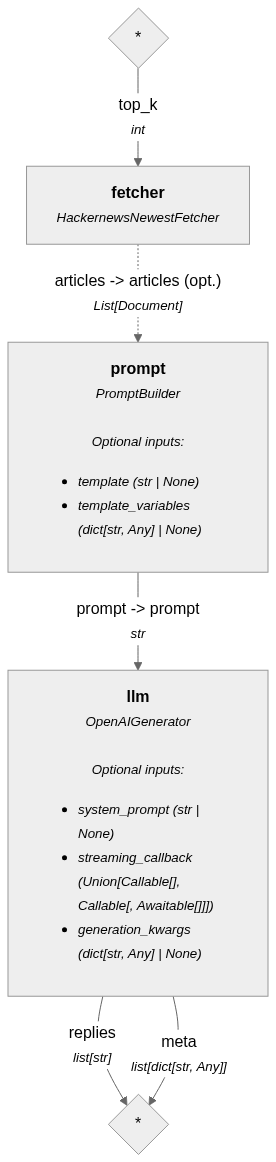

In [16]:
summarizer_pipeline.show()

In [18]:
summaries = summarizer_pipeline.run({"fetcher": {"top_k": 3}})

print(summaries["llm"]["replies"][0])

Can't download <Response [200]>, skipped
- 1.1.1.1 CNAME ordering outage (Jan 8, 2026)  
  Cloudflare describes a production incident where a memory-optimization change altered the order of DNS answer records so CNAMEs sometimes appeared after final A/AAAA answers. Some DNS clients (notably glibc's getaddrinfo and certain Cisco switches) parse answers sequentially and expect CNAMEs first, so they failed — causing resolution errors and device crashes. The change was deployed Jan 7–8, rolled back when the problem was found, and Cloudflare reverted the reordering permanently. Root cause: a 40-year-old ambiguity in RFC 1034 about ordering of different RRsets; Cloudflare proposes an IETF Internet-Draft to clarify expected behavior.

- Martin Luther King Jr. — Nonviolence (essay summary)  
  A concise overview of King’s commitment to nonviolent resistance: influenced by Thoreau and Gandhi, he adopted nonviolence as both moral principle and practical method during the Montgomery bus boycott. 

In [19]:
prompt_template = """
You will be provided a few of the top posts in HackerNews, followed by their URL.
For each post, provide a brief summary followed by the URL the full post can be found at.

Posts:
{% for article in articles %}
    {{ article.content }}
    URL: {{ article.meta["url"] }}
{% endfor %}
"""

prompt_builder = PromptBuilder(template=prompt_template)
fetcher = HackernewsNewestFetcher()
llm = OpenAIGenerator()

summarizer_pipeline = Pipeline()
summarizer_pipeline.add_component("fetcher", fetcher)
summarizer_pipeline.add_component("prompt", prompt_builder)
summarizer_pipeline.add_component("llm", llm)

summarizer_pipeline.connect("fetcher.articles", "prompt.articles")
summarizer_pipeline.connect("prompt", "llm")

PromptBuilder has 1 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


🚅 Components
  - fetcher: HackernewsNewestFetcher
  - prompt: PromptBuilder
  - llm: OpenAIGenerator
🛤️ Connections
  - fetcher.articles -> prompt.articles (List[Document])
  - prompt.prompt -> llm.prompt (str)

In [20]:
summaries = summarizer_pipeline.run({"fetcher": {"top_k": 2}})

print(summaries["llm"]["replies"][0])

Can't download <Response [200]>, skipped
Summary: An overview of Martin Luther King Jr.’s adoption and development of nonviolent resistance as both moral principle and practical method. It traces influences (Thoreau, Gandhi), King’s experience leading the Montgomery bus boycott with guidance from Bayard Rustin and Glenn Smiley, his six core principles of nonviolence (resist evil without violence; seek friendship of opponents; oppose evil, not people; accept suffering without retaliation; avoid external and internal violence; maintain faith in the future), and his increasing commitment after trips to India and in response to critiques from Black Power advocates. The piece includes King’s warnings about modern violence (“nonviolence or nonexistence”) and his famous claim that “darkness cannot drive out darkness; only light can do that.”

URL: https://kinginstitute.stanford.edu/nonviolence
